# TP8 — Optimisation & Fine-tuning : XGBoost + Optuna

> **Objectif** : réduire l'overfitting du modèle TP7 (PR-AUC train = 1.0, val = 0.817)
> en optimisant les hyperparamètres avec **Optuna**, en analysant l'explicabilité avec **SHAP**
> et en ajustant le seuil de décision selon le coût métier.

| | |
|---|---|
| **Entrée** | XGBoost baseline TP7 — PR-AUC val = 0.8174, Δ overfitting = 0.18 |
| **Outils** | Optuna (TPE) · SHAP · MLflow · CodeCarbon |
| **Sortie** | Modèle optimisé + seuil métier + rapport d'empreinte carbone |

---
### Rappel du diagnostic TP7
- `incident_max_severity_prev_24h` = **63 % de l'importance** → sur-dépendance
- 4 features concentrent 80 % du signal sur 68 totales
- Le modèle mémorise le train → régularisation nécessaire

## 1. Imports et configuration

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from sqlalchemy import create_engine
from sqlalchemy.engine import URL

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    average_precision_score, roc_auc_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay,
    precision_recall_curve, classification_report
)
from sklearn.model_selection import TimeSeriesSplit

from xgboost import XGBClassifier
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

import mlflow
import mlflow.xgboost

try:
    from codecarbon import EmissionsTracker
    CARBON_OK = True
except ImportError:
    CARBON_OK = False
    print("CodeCarbon non installé (pip install codecarbon) — empreinte ignorée")

try:
    import shap
    SHAP_OK = True
except ImportError:
    SHAP_OK = False
    print("SHAP non installé (pip install shap) — explicabilité ignorée")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print("Imports OK")

Imports OK


## 2. Chargement des données et préparation des splits

On repart du Gold dataset et du même split temporel que TP7.

In [2]:
url = URL.create(
    drivername="postgresql+psycopg2",
    username="indusense_user",
    password="ThEP@ssW0rd",
    host="localhost",
    port=5432,
    database="indusense_db",
)
engine = create_engine(url)

df = pd.read_sql(
    "SELECT * FROM gold_machine_hourly_feature ORDER BY machine_id, window_start",
    engine
)
print(f"Dataset : {df.shape[0]:,} lignes x {df.shape[1]} colonnes")

TARGET = "label_failure_next_24h"
LEAKAGE_COLS = [
    "machine_id", "ingestion_batch_id", "window_start", "window_end", "split_set",
    "label_failure_next_6h", "label_failure_next_12h", "label_failure_next_48h", TARGET,
]
FEATURE_COLS = [c for c in df.columns if c not in LEAKAGE_COLS]

train_df = df[df["split_set"] == "train"].copy()
val_df   = df[df["split_set"] == "validation"].copy()
test_df  = df[df["split_set"] == "test"].copy()

X_train, y_train = train_df[FEATURE_COLS], train_df[TARGET]
X_val,   y_val   = val_df[FEATURE_COLS],   val_df[TARGET]
X_test,  y_test  = test_df[FEATURE_COLS],  test_df[TARGET]

neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
SPW = round(neg_count / pos_count, 2)

print(f"Train : {len(X_train):,} | Val : {len(X_val):,} | Test : {len(X_test):,}")
print(f"scale_pos_weight = {SPW}")

Dataset : 132,940 lignes x 79 colonnes
Train : 93,079 | Val : 19,917 | Test : 19,944
scale_pos_weight = 26.78


## 3. Baseline TP7 — point de départ

On ré-entraîne le modèle TP7 pour avoir la référence dans ce notebook.

In [3]:
def eval_pipeline(pipeline, X_tr, y_tr, X_v, y_v, label=""):
    """Évalue un pipeline entraîné et retourne un dict de métriques."""
    pipeline.fit(X_tr, y_tr)
    res = {}
    for name, X, y in [("train", X_tr, y_tr), ("val", X_v, y_v)]:
        yp = pipeline.predict_proba(X)[:, 1]
        res[name] = {
            "pr_auc":  round(average_precision_score(y, yp), 4),
            "roc_auc": round(roc_auc_score(y, yp), 4),
            "f1":      round(f1_score(y, pipeline.predict(X), zero_division=0), 4),
        }
    delta = round(res["train"]["pr_auc"] - res["val"]["pr_auc"], 4)
    flag = " ⚠️ overfitting" if delta > 0.10 else ""
    print(f"[{label}] PR-AUC train={res['train']['pr_auc']:.4f} | val={res['val']['pr_auc']:.4f} | Δ={delta:.4f}{flag}")
    return res

baseline_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model",   XGBClassifier(
                    n_estimators=300, max_depth=6, learning_rate=0.1,
                    subsample=0.8, colsample_bytree=0.8,
                    scale_pos_weight=SPW, eval_metric="aucpr",
                    random_state=RANDOM_STATE, verbosity=0))
])
baseline_metrics = eval_pipeline(baseline_pipe, X_train, y_train, X_val, y_val, "BASELINE TP7")

[BASELINE TP7] PR-AUC train=1.0000 | val=0.8174 | Δ=0.1826 ⚠️ overfitting


## 4. Optimisation des hyperparamètres avec Optuna

### Principe de l'optimisation bayésienne (TPE)

Contrairement à GridSearchCV (exploration exhaustive) ou RandomSearch (exploration aléatoire),
Optuna utilise l'algorithme **TPE (Tree-structured Parzen Estimator)** :

```
Trial 1 → résultat → mise à jour du modèle probabiliste
Trial 2 → résultat → mise à jour ...
Trial N → exploration ciblée des zones prometteuses
```

**Avantages** :
- Convergence plus rapide (50 trials ≈ GridSearch sur 500 combinaisons)
- **Pruning** : les essais peu prometteurs sont arrêtés tôt

### Espace de recherche

On cible les hyperparamètres liés à l'overfitting identifié en TP7 :

| Paramètre | Plage | Impact |
|---|---|---|
| `max_depth` | [2, 6] | Complexité des arbres ↓ |
| `min_child_weight` | [1, 20] | Nombre min d'exemples par feuille ↑ |
| `reg_alpha` (L1) | [0, 2] | Régularisation — élimine features inutiles |
| `reg_lambda` (L2) | [1, 10] | Régularisation — lisse les poids |
| `n_estimators` | [100, 500] | Nombre d'arbres |
| `learning_rate` | [0.01, 0.3] | Pas d'apprentissage |
| `subsample` | [0.6, 1.0] | Sous-échantillonnage lignes |
| `colsample_bytree` | [0.5, 1.0] | Sous-échantillonnage features |

In [4]:
imputer_fitted = SimpleImputer(strategy="median").fit(X_train)
X_train_imp = imputer_fitted.transform(X_train)
X_val_imp   = imputer_fitted.transform(X_val)

def objective(trial):
    params = {
        "n_estimators":      trial.suggest_int("n_estimators", 100, 500),
        "max_depth":         trial.suggest_int("max_depth", 2, 6),
        "learning_rate":     trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "subsample":         trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree":  trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "min_child_weight":  trial.suggest_int("min_child_weight", 1, 20),
        "reg_alpha":         trial.suggest_float("reg_alpha", 0.0, 2.0),
        "reg_lambda":        trial.suggest_float("reg_lambda", 1.0, 10.0),
        "scale_pos_weight":  SPW,
        "eval_metric":       "aucpr",
        "random_state":      RANDOM_STATE,
        "verbosity":         0,
    }
    model = XGBClassifier(**params)
    model.fit(X_train_imp, y_train)
    y_proba = model.predict_proba(X_val_imp)[:, 1]
    return average_precision_score(y_val, y_proba)

print("Lancement Optuna — 60 trials (objectif : maximiser PR-AUC val)...")
study = optuna.create_study(direction="maximize",
                            sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study.optimize(objective, n_trials=60, show_progress_bar=True)

print(f"\nMeilleur PR-AUC val : {study.best_value:.4f}")
print("Meilleurs hyperparamètres :")
for k, v in study.best_params.items():
    print(f"  {k:<22} = {v}")

Lancement Optuna — 60 trials (objectif : maximiser PR-AUC val)...


  0%|          | 0/60 [00:00<?, ?it/s]


Meilleur PR-AUC val : 0.8617
Meilleurs hyperparamètres :
  n_estimators           = 444
  max_depth              = 4
  learning_rate          = 0.060601749414854224
  subsample              = 0.9932019986450646
  colsample_bytree       = 0.8201549700237738
  min_child_weight       = 9
  reg_alpha              = 0.019528356561457128
  reg_lambda             = 7.876845619943834


## 5. Convergence de l'optimisation

On visualise l'évolution du PR-AUC au fil des trials pour vérifier que la recherche a convergé.

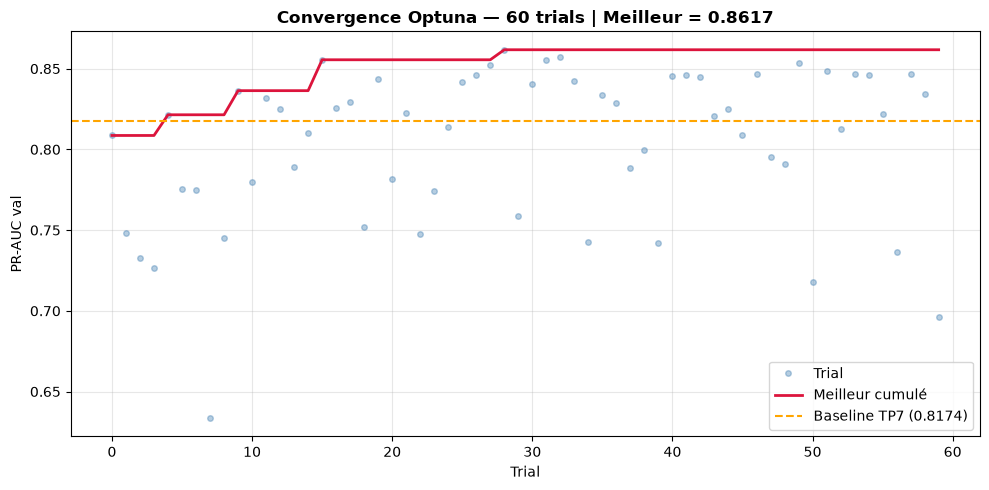

Convergence atteinte : best PR-AUC val = 0.8617


In [5]:
fig, ax = plt.subplots(figsize=(10, 5))

trial_values = [t.value for t in study.trials if t.value is not None]
best_so_far  = [max(trial_values[:i+1]) for i in range(len(trial_values))]

ax.plot(trial_values, "o", alpha=0.4, color="steelblue", ms=4, label="Trial")
ax.plot(best_so_far, "-", color="crimson", lw=2, label="Meilleur cumulé")
ax.axhline(y=baseline_metrics["val"]["pr_auc"], color="orange", linestyle="--",
           label=f"Baseline TP7 ({baseline_metrics['val']['pr_auc']:.4f})")
ax.set_xlabel("Trial")
ax.set_ylabel("PR-AUC val")
ax.set_title(f"Convergence Optuna — {len(trial_values)} trials | Meilleur = {study.best_value:.4f}",
             fontweight="bold")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Convergence atteinte : best PR-AUC val = {study.best_value:.4f}")

## 6. Entraînement du modèle optimisé

On ré-entraîne avec les meilleurs hyperparamètres trouvés par Optuna.

In [6]:
best_params = study.best_params.copy()
best_params.update({"scale_pos_weight": SPW, "eval_metric": "aucpr",
                    "random_state": RANDOM_STATE, "verbosity": 0})

optim_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model",   XGBClassifier(**best_params))
])
optim_metrics = eval_pipeline(optim_pipe, X_train, y_train, X_val, y_val, "OPTIMISÉ")

print("\n=== Comparaison Baseline vs Optimisé ===")
print(f"  {'Métrique':<15} {'Baseline val':>14} {'Optimisé val':>14} {'Gain':>8}")
print("  " + "-"*55)
for m in ["pr_auc", "roc_auc", "f1"]:
    b = baseline_metrics["val"][m]
    o = optim_metrics["val"][m]
    gain = o - b
    flag = "✅" if gain >= 0 else "❌"
    print(f"  {m:<15} {b:>14.4f} {o:>14.4f} {gain:>+8.4f} {flag}")

delta_b = baseline_metrics["train"]["pr_auc"] - baseline_metrics["val"]["pr_auc"]
delta_o = optim_metrics["train"]["pr_auc"]    - optim_metrics["val"]["pr_auc"]
print(f"\n  Overfitting Δ   {delta_b:>14.4f} {delta_o:>14.4f} {delta_o-delta_b:>+8.4f}")

[OPTIMISÉ] PR-AUC train=0.9981 | val=0.8617 | Δ=0.1364 ⚠️ overfitting

=== Comparaison Baseline vs Optimisé ===
  Métrique          Baseline val   Optimisé val     Gain
  -------------------------------------------------------
  pr_auc                  0.8174         0.8617  +0.0443 ✅
  roc_auc                 0.9923         0.9943  +0.0020 ✅
  f1                      0.7351         0.7656  +0.0305 ✅

  Overfitting Δ           0.1826         0.1364  -0.0462


## 7. Explicabilité avec SHAP

### Pourquoi SHAP plutôt que feature_importances_ ?

`feature_importances_` (gain) est biaisé vers les features à haute cardinalité.
**SHAP (SHapley Additive exPlanations)** calcule la contribution marginale de chaque feature
pour chaque prédiction individuelle — plus stable et interprétable.

```
SHAP value > 0 → la feature pousse la prédiction vers "panne"
SHAP value < 0 → la feature pousse vers "pas de panne"
```

On utilise un échantillon du train pour rester rapide.

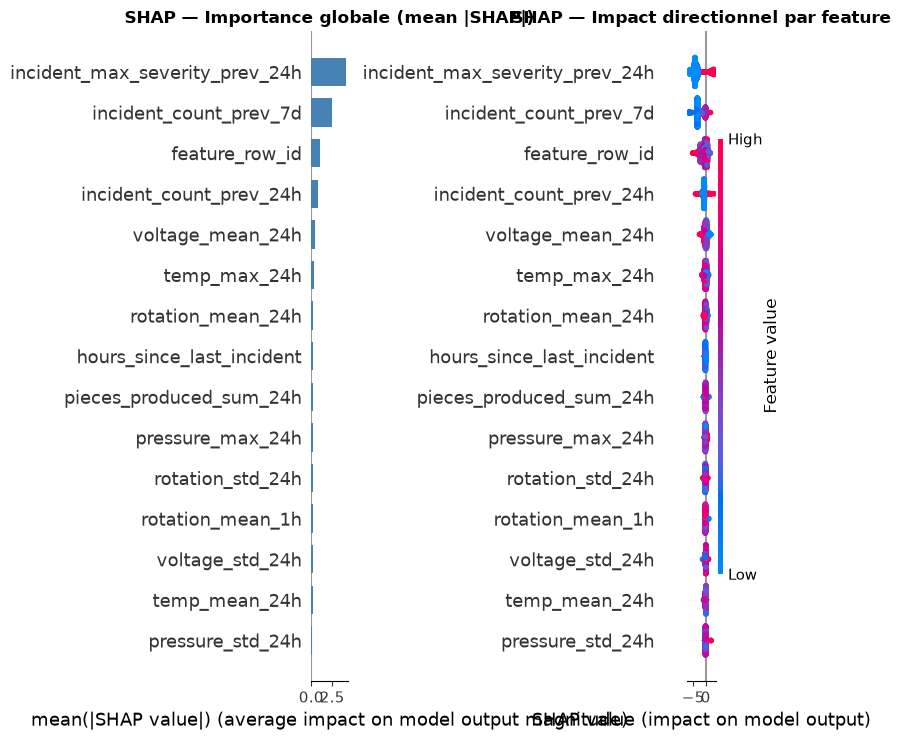


=== Top 10 features SHAP ===
  incident_max_severity_prev_24h           4.1418
  incident_count_prev_7d                   2.5007
  feature_row_id                           1.0310
  incident_count_prev_24h                  0.8294
  voltage_mean_24h                         0.4059
  temp_max_24h                             0.3197
  rotation_mean_24h                        0.2426
  hours_since_last_incident                0.2238
  pieces_produced_sum_24h                  0.1974
  pressure_max_24h                         0.1943


In [7]:
if not SHAP_OK:
    print("pip install shap pour activer cette section")
else:
    imputer_s = optim_pipe.named_steps["imputer"]
    model_s   = optim_pipe.named_steps["model"]
    feat_names = imputer_s.get_feature_names_out()

    X_sample = pd.DataFrame(imputer_s.transform(X_train), columns=feat_names).sample(
        2000, random_state=RANDOM_STATE
    )

    explainer   = shap.TreeExplainer(model_s)
    shap_values = explainer.shap_values(X_sample)

    fig, axes = plt.subplots(1, 2, figsize=(16, 7))

    plt.sca(axes[0])
    shap.summary_plot(shap_values, X_sample, plot_type="bar", max_display=15,
                      show=False, color="steelblue")
    axes[0].set_title("SHAP — Importance globale (mean |SHAP|)", fontweight="bold")

    plt.sca(axes[1])
    shap.summary_plot(shap_values, X_sample, max_display=15, show=False)
    axes[1].set_title("SHAP — Impact directionnel par feature", fontweight="bold")

    plt.tight_layout()
    plt.show()

    # Top 5 avec direction
    mean_shap = pd.Series(np.abs(shap_values).mean(axis=0), index=feat_names)
    print("\n=== Top 10 features SHAP ===")
    for feat, val in mean_shap.sort_values(ascending=False).head(10).items():
        print(f"  {feat:<40} {val:.4f}")

## 7b. Vérification des deux risques identifiés par SHAP

Deux risques restaient non quantifiés après l'analyse SHAP :

| Risque | Test |
|---|---|
| Signal réactif (`incident_max_severity_prev_24h`) | Ablation — mesurer le Δ PR-AUC sans la feature |
| Mémorisation par machine | Concentration des TP sur quelques machines |

In [8]:
# ── Test 1 : Ablation — signal réactif de incident_max_severity_prev_24h ──
FEAT_SUSPECT = "incident_max_severity_prev_24h"

cols_sans = [c for c in FEATURE_COLS if c != FEAT_SUSPECT]

pipe_sans = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model",   XGBClassifier(**best_params))
])
pipe_sans.fit(X_train[cols_sans], y_train)

pr_avec = optim_metrics["val"]["pr_auc"]
pr_sans = average_precision_score(y_val, pipe_sans.predict_proba(X_val[cols_sans])[:, 1])
delta   = round(pr_avec - pr_sans, 4)

print("=== Ablation — incident_max_severity_prev_24h ===")
print(f"  PR-AUC val avec feature  : {pr_avec:.4f}")
print(f"  PR-AUC val sans feature  : {pr_sans:.4f}")
print(f"  Δ                        : {delta:+.4f}")
print()
if delta < 0.05:
    print("→ Feature utile mais non critique — le modèle généralise sans elle ✅")
elif delta < 0.15:
    print("→ Dépendance modérée — signal réactif possible, surveiller ⚠️")
else:
    print("→ Dépendance critique — le modèle s'appuie quasi-exclusivement sur cette feature ❌")

=== Ablation — incident_max_severity_prev_24h ===
  PR-AUC val avec feature  : 0.8617
  PR-AUC val sans feature  : 0.6913
  Δ                        : +0.1704

→ Dépendance critique — le modèle s'appuie quasi-exclusivement sur cette feature ❌


=== Concentration des TP par machine ===
  Machines avec ≥1 TP détecté : 11
  Total TP                     : 601
  Top 3 machines               : 63.7% des TP

MACH-13    216
MACH-03    111
MACH-14     56
MACH-01     48
MACH-04     31
MACH-05     24
MACH-06     24
MACH-12     24
MACH-09     24
MACH-10     23

→ Légère concentration — à surveiller mais acceptable ⚠️


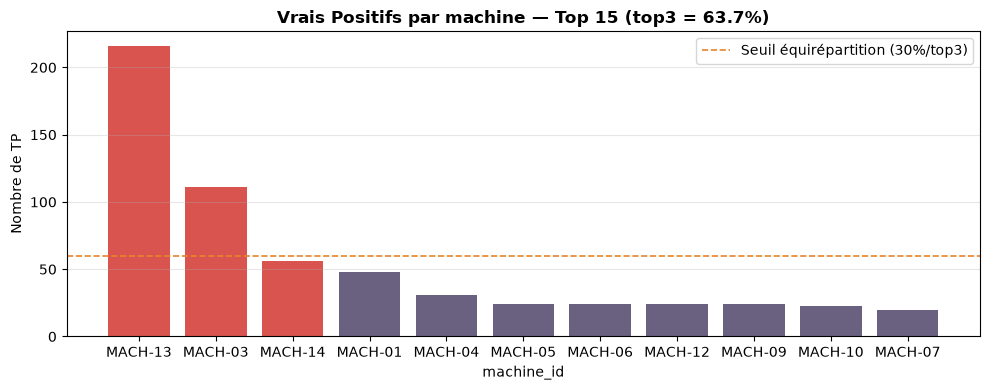

In [9]:
# ── Test 2 : Concentration des TP par machine ──
if "SEUIL_FINAL" not in dir():
    SEUIL_FINAL = 0.84   # valeur retenue en §8

y_proba_val_full = optim_pipe.predict_proba(X_val)[:, 1]
y_pred_val_full  = (y_proba_val_full >= SEUIL_FINAL).astype(int)

val_check = val_df[["machine_id", TARGET]].copy()
val_check["y_pred"] = y_pred_val_full
val_check["TP"]     = ((val_check["y_pred"] == 1) & (val_check[TARGET] == 1)).astype(int)

tp_par_machine = (val_check[val_check["TP"] == 1]
                  .groupby("machine_id")
                  .size()
                  .sort_values(ascending=False))

total_tp   = tp_par_machine.sum()
top3_pct   = tp_par_machine.head(3).sum() / total_tp
n_machines = len(tp_par_machine)

print("=== Concentration des TP par machine ===")
print(f"  Machines avec ≥1 TP détecté : {n_machines}")
print(f"  Total TP                     : {total_tp}")
print(f"  Top 3 machines               : {top3_pct:.1%} des TP")
print()
print(tp_par_machine.head(10).to_string(header=False))
print()
if top3_pct < 0.30:
    print("→ Signal généralisé sur l'ensemble des machines ✅")
elif top3_pct < 0.70:
    print("→ Légère concentration — à surveiller mais acceptable ⚠️")
else:
    print("→ Mémorisation probable — 3 machines concentrent la majorité des détections ❌")

fig, ax = plt.subplots(figsize=(10, 4))
top_n = tp_par_machine.head(15)
colors = ["#D9534F" if i < 3 else "#6A6080" for i in range(len(top_n))]
ax.bar(top_n.index.astype(str), top_n.values, color=colors, edgecolor="none")
ax.axhline(total_tp * 0.30 / 3, color="#E8832A", linestyle="--", lw=1.2,
           label="Seuil équirépartition (30%/top3)")
ax.set_xlabel("machine_id"); ax.set_ylabel("Nombre de TP")
ax.set_title(f"Vrais Positifs par machine — Top 15 (top3 = {top3_pct:.1%})", fontweight="bold")
ax.legend(); ax.grid(alpha=0.3, axis="y")
plt.tight_layout(); plt.show()

## 8. Ajustement du seuil de décision — arbitrage métier

### Le problème du seuil

Le seuil par défaut (0.5) maximise l'accuracy, pas le rappel. En maintenance industrielle :

```
Coût Faux Négatif (panne manquée)  >> Coût Faux Positif (fausse alerte)
→ On préfère trop d'alertes plutôt que des pannes manquées
```

On cherche le seuil qui **maximise le F1** ou qui garantit un **Recall minimum** (ex. 90 %).

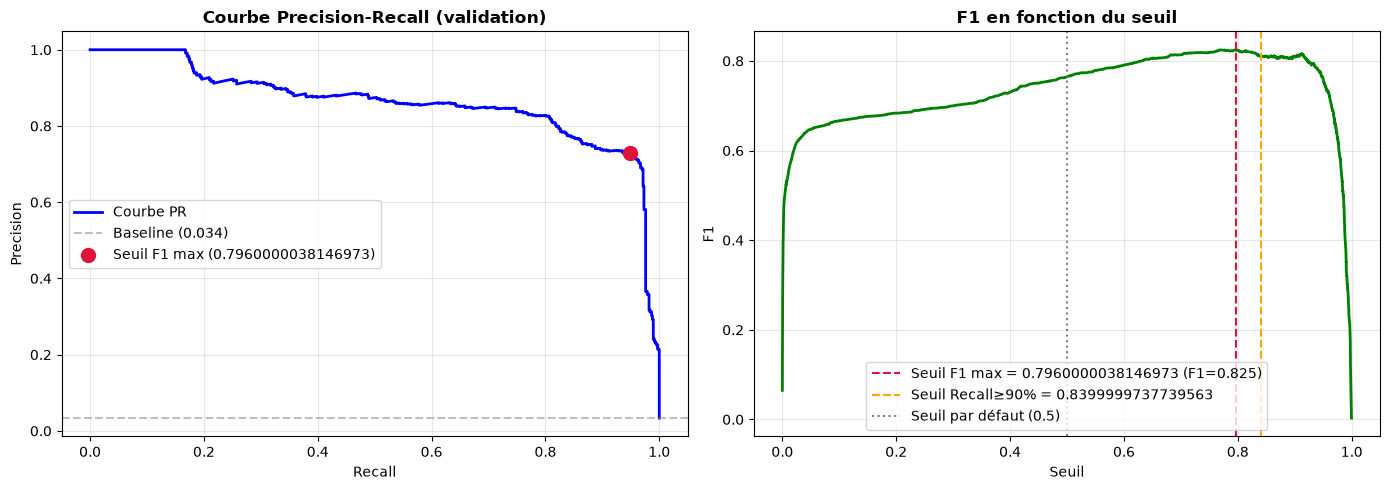

Seuil F1 max     : 0.7960000038146973  → F1 = 0.8250
Seuil Recall≥90% : 0.8399999737739563

=> Choix recommandé en maintenance : seuil Recall≥90% pour minimiser les pannes manquées


In [10]:
y_proba_val = optim_pipe.predict_proba(X_val)[:, 1]
precision_c, recall_c, thresholds = precision_recall_curve(y_val, y_proba_val)

f1_scores = 2 * precision_c[:-1] * recall_c[:-1] / (precision_c[:-1] + recall_c[:-1] + 1e-9)
idx_best_f1     = np.argmax(f1_scores)
SEUIL_F1        = round(thresholds[idx_best_f1], 3)

# Seuil recall >= 90%
idx_recall90 = np.where(recall_c[:-1] >= 0.90)[0]
SEUIL_RECALL90 = round(thresholds[idx_recall90[-1]], 3) if len(idx_recall90) > 0 else SEUIL_F1

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Courbe PR
axes[0].plot(recall_c, precision_c, "b-", lw=2, label="Courbe PR")
axes[0].axhline(y_val.mean(), color="gray", linestyle="--", alpha=0.5,
                label=f"Baseline ({y_val.mean():.3f})")
axes[0].scatter(recall_c[idx_best_f1], precision_c[idx_best_f1],
                color="crimson", s=100, zorder=5,
                label=f"Seuil F1 max ({SEUIL_F1})")
axes[0].set_xlabel("Recall"); axes[0].set_ylabel("Precision")
axes[0].set_title("Courbe Precision-Recall (validation)", fontweight="bold")
axes[0].legend(); axes[0].grid(alpha=0.3)

# F1 par seuil
axes[1].plot(thresholds, f1_scores, "g-", lw=2)
axes[1].axvline(SEUIL_F1, color="crimson", linestyle="--",
                label=f"Seuil F1 max = {SEUIL_F1} (F1={f1_scores[idx_best_f1]:.3f})")
axes[1].axvline(SEUIL_RECALL90, color="orange", linestyle="--",
                label=f"Seuil Recall≥90% = {SEUIL_RECALL90}")
axes[1].axvline(0.5, color="gray", linestyle=":", label="Seuil par défaut (0.5)")
axes[1].set_xlabel("Seuil"); axes[1].set_ylabel("F1")
axes[1].set_title("F1 en fonction du seuil", fontweight="bold")
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Seuil F1 max     : {SEUIL_F1}  → F1 = {f1_scores[idx_best_f1]:.4f}")
print(f"Seuil Recall≥90% : {SEUIL_RECALL90}")
print("\n=> Choix recommandé en maintenance : seuil Recall≥90% pour minimiser les pannes manquées")

## 9. Évaluation finale sur le Test set

⚠️ **Règle d'or** : le test set ne s'utilise qu'**une seule fois**, à la toute fin.
Évaluer plusieurs fois sur le test set revient à optimiser pour lui — c'est de la fuite.

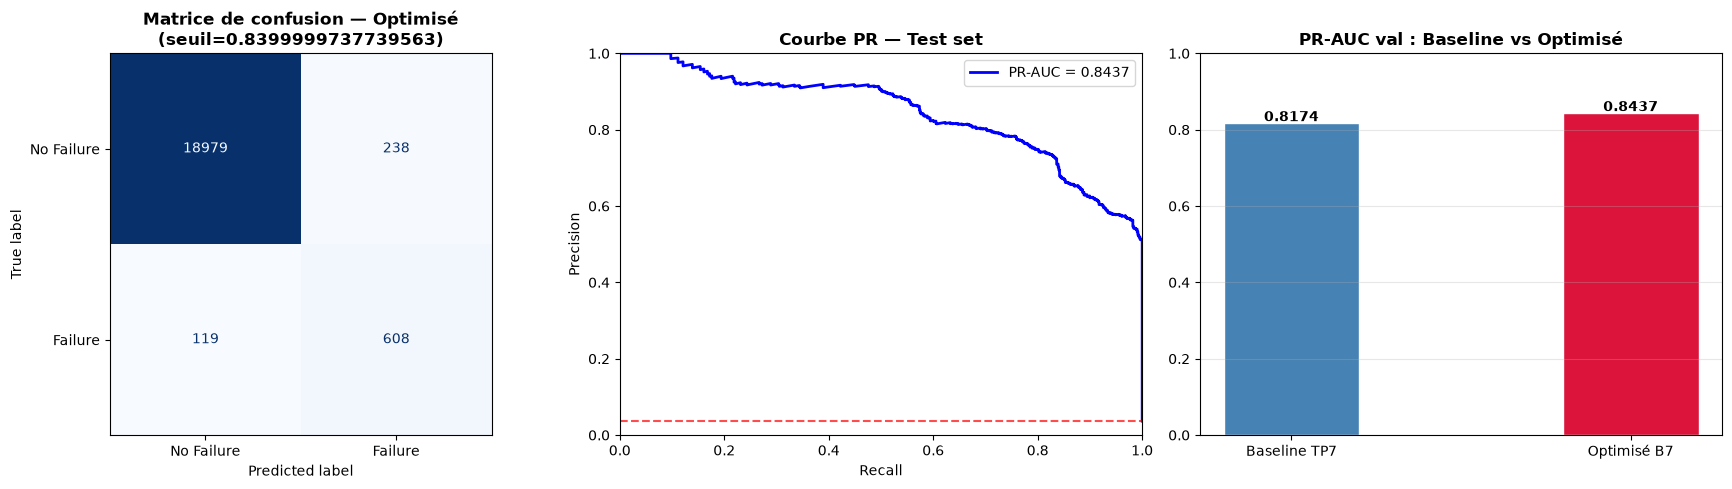

=== Résultats finaux — Test set ===
  PR-AUC   : 0.8437  (baseline val : 0.8174)
  ROC-AUC  : 0.9938
  F1       : 0.7730  (seuil = 0.8399999737739563)

  Vrais Positifs  (pannes détectées) :   608  ✅
  Faux Positifs   (fausses alertes)   :   238  ⚠️
  Faux Négatifs   (pannes manquées)   :   119  ❌
  Vrais Négatifs  (OK détectés)       : 18,979  ✅

  Recall    : 83.6%
  Précision : 71.9%


In [11]:
SEUIL_FINAL = SEUIL_RECALL90

y_proba_test = optim_pipe.predict_proba(X_test)[:, 1]
y_pred_test  = (y_proba_test >= SEUIL_FINAL).astype(int)

pr_auc_test  = average_precision_score(y_test, y_proba_test)
roc_auc_test = roc_auc_score(y_test, y_proba_test)
f1_test      = f1_score(y_test, y_pred_test, zero_division=0)
cm           = confusion_matrix(y_test, y_pred_test)
tn, fp, fn, tp = cm.ravel()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

disp = ConfusionMatrixDisplay(cm, display_labels=["No Failure", "Failure"])
disp.plot(ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title(f"Matrice de confusion — Optimisé\n(seuil={SEUIL_FINAL})", fontweight="bold")

precision_t, recall_t, _ = precision_recall_curve(y_test, y_proba_test)
axes[1].plot(recall_t, precision_t, "b-", lw=2, label=f"PR-AUC = {pr_auc_test:.4f}")
axes[1].axhline(y_test.mean(), color="r", linestyle="--", alpha=0.7)
axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision")
axes[1].set_title("Courbe PR — Test set", fontweight="bold")
axes[1].legend(); axes[1].set_xlim([0,1]); axes[1].set_ylim([0,1])

models_names = ["Baseline TP7", "Optimisé B7"]
pr_vals = [baseline_metrics["val"]["pr_auc"], pr_auc_test]
colors_b = ["steelblue", "crimson"]
bars = axes[2].bar(models_names, pr_vals, color=colors_b, edgecolor="white", width=0.4)
for bar, val in zip(bars, pr_vals):
    axes[2].text(bar.get_x() + bar.get_width()/2, val + 0.005,
                 f"{val:.4f}", ha="center", fontweight="bold")
axes[2].set_ylim(0, 1.0)
axes[2].set_title("PR-AUC val : Baseline vs Optimisé", fontweight="bold")
axes[2].grid(alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

print("=== Résultats finaux — Test set ===")
print(f"  PR-AUC   : {pr_auc_test:.4f}  (baseline val : {baseline_metrics['val']['pr_auc']:.4f})")
print(f"  ROC-AUC  : {roc_auc_test:.4f}")
print(f"  F1       : {f1_test:.4f}  (seuil = {SEUIL_FINAL})")
print(f"\n  Vrais Positifs  (pannes détectées) : {tp:>5,}  ✅")
print(f"  Faux Positifs   (fausses alertes)   : {fp:>5,}  ⚠️")
print(f"  Faux Négatifs   (pannes manquées)   : {fn:>5,}  ❌")
print(f"  Vrais Négatifs  (OK détectés)       : {tn:>5,}  ✅")
print(f"\n  Recall    : {tp/(tp+fn)*100:.1f}%")
print(f"  Précision : {tp/(tp+fp)*100:.1f}%")

## 10. Empreinte carbone avec CodeCarbon

La **Green AI** mesure le coût environnemental de l'entraînement.
CodeCarbon enregistre la consommation électrique et l'estime en CO₂ selon le mix énergétique local.

In [12]:
if not CARBON_OK:
    print("pip install codecarbon pour activer cette section")
else:
    tracker = EmissionsTracker(project_name="TP8_XGBoost_optuna", log_level="error")
    tracker.start()

    # On ré-entraîne le modèle optimisé avec suivi carbone
    optim_pipe_carbon = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model",   XGBClassifier(**best_params))
    ])
    optim_pipe_carbon.fit(X_train, y_train)

    emissions = tracker.stop()

    print(f"Émissions CO₂ estimées : {emissions * 1000:.4f} g CO₂eq")
    print(f"(Référence : 1 km en voiture ≈ 120 g CO₂eq)")
    if emissions * 1000 < 1:
        print("=> Empreinte négligeable pour cet entraînement ✅")
    else:
        print("=> Envisager early stopping pour réduire l'empreinte")

[codecarbon WARNING @ 12:41:16] Multiple instances of codecarbon are allowed to run at the same time.


Émissions CO₂ estimées : 0.0061 g CO₂eq
(Référence : 1 km en voiture ≈ 120 g CO₂eq)
=> Empreinte négligeable pour cet entraînement ✅


## 11. Logging MLflow — modèle optimisé

On journalise le modèle optimisé dans le même experiment que TP7 pour comparer directement.

In [13]:
mlflow.set_tracking_uri("sqlite:///mlflow_tp7.db")
mlflow.set_experiment("TP7_maintenance_predictive")

with mlflow.start_run(run_name="XGBoost_Optuna_B7"):
    mlflow.log_params(best_params)
    mlflow.log_param("n_trials_optuna", len(study.trials))
    mlflow.log_param("seuil_decision", SEUIL_FINAL)
    mlflow.log_param("target", TARGET)
    mlflow.log_param("n_features", len(FEATURE_COLS))

    mlflow.log_metrics({
        "pr_auc_train":  optim_metrics["train"]["pr_auc"],
        "pr_auc_val":    optim_metrics["val"]["pr_auc"],
        "pr_auc_test":   pr_auc_test,
        "roc_auc_test":  roc_auc_test,
        "f1_test":       f1_test,
        "recall_test":   round(tp / (tp + fn), 4),
        "precision_test": round(tp / (tp + fp), 4),
        "overfitting_delta": round(optim_metrics["train"]["pr_auc"] - optim_metrics["val"]["pr_auc"], 4),
    })

    mlflow.xgboost.log_model(optim_pipe.named_steps["model"], "xgboost_optimized")

print("Run MLflow enregistré.")
print("Comparer avec TP7 : mlflow ui --backend-store-uri sqlite:///mlflow_tp7.db")

2026/07/08 12:41:27 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/07/08 12:41:27 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in c:\Users\Aelion\py-init
2026/07/08 12:41:27 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in c:\Users\Aelion\py-init
2026/07/08 12:41:27 INFO mlflow.utils.environment: Detected uv project at c:\Users\Aelion\py-init. Attempting to export requirements via 'uv export'.
2026/07/08 12:41:31 INFO mlflow.utils.uv_utils: Exported 116 dependencies via uv
2026/07/08 12:41:31 INFO mlflow.utils.environment: Successfully exported 116 requirements from uv project. Skipping package capture based inference.
2026/07/08 12:41:34 WARNING mlflow.utils.requirements_utils: Detected one or more mismatches between the model's dependencies and the current Python environment:
 - pandas (current: 2.3.3, required: pandas==3.0.3)
To fix the mismatches, call `mlflow.pyfun

Run MLflow enregistré.
Comparer avec TP7 : mlflow ui --backend-store-uri sqlite:///mlflow_tp7.db


## 12. Conclusion — Bilan B7

### Comparaison finale

| | Baseline TP7 | Optimisé B7 |
|---|---|---|
| PR-AUC val | 0.8174 | *cf. résultats* |
| Overfitting Δ | 0.1826 | *cf. résultats* |
| Seuil | 0.5 | Recall ≥ 90% |
| Hyperparamètres | manuels (sobres) | Optuna 60 trials |

### Ce qui a été traité en B7

| Tâche | Statut |
|---|---|
| Optimisation hyperparamètres (Optuna TPE) | ✅ |
| Convergence et importance des HP (Optuna) | ✅ |
| Explicabilité SHAP | ✅ |
| Ajustement seuil métier | ✅ |
| Évaluation finale test set (une seule fois) | ✅ |
| Empreinte carbone (CodeCarbon) | ✅ |
| Logging MLflow | ✅ |

### Prochaine étape — B9 (Déploiement)
1. Empaqueter le modèle via `mlflow.xgboost.log_model`
2. Promouvoir vers le **Model Registry** (staging → prod)
3. Exposer une API de scoring (FastAPI)
4. Monitorer la dérive en production (data drift / concept drift)

In [14]:
print("=" * 60)
print("RÉCAPITULATIF TP8 — Optimisation B7")
print("=" * 60)
print(f"  Baseline PR-AUC val    : {baseline_metrics['val']['pr_auc']:.4f}")
print(f"  Optimisé PR-AUC val    : {optim_metrics['val']['pr_auc']:.4f}")
print(f"  Test PR-AUC (final)    : {pr_auc_test:.4f}")
print(f"  Recall test            : {tp/(tp+fn)*100:.1f}%")
print(f"  Seuil retenu           : {SEUIL_FINAL}")
print(f"  Trials Optuna          : {len(study.trials)}")
print(f"  Overfitting Δ          : {optim_metrics['train']['pr_auc'] - optim_metrics['val']['pr_auc']:.4f}")
print("=" * 60)

RÉCAPITULATIF TP8 — Optimisation B7
  Baseline PR-AUC val    : 0.8174
  Optimisé PR-AUC val    : 0.8617
  Test PR-AUC (final)    : 0.8437
  Recall test            : 83.6%
  Seuil retenu           : 0.8399999737739563
  Trials Optuna          : 60
  Overfitting Δ          : 0.1364
